# Load the Env

In [37]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]= "True"
os.environ["LANGCHAIN_PROJECT"]= "ReAct Agent"


### Import the tools api built in

In [38]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [39]:
#initialize the arxiv

arxiv_api = ArxivAPIWrapper(top_k_results=3,doc_content_chars_max=300)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api)
arxiv.name

'arxiv'

In [40]:
#initialize the wikipedia

wiki_api = WikipediaAPIWrapper(top_k_results=3,doc_content_chars_max=300)
wiki = WikipediaQueryRun(api_wrapper=wiki_api)
wiki.name

'wikipedia'

In [41]:
#tavily initialize

from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults(max=3)

In [42]:
arxiv.invoke("all you need attention")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [43]:
print(wiki.name)

result = wiki.invoke("LangChain")
print(result)

wikipedia
Page: LangChain
Summary: LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis a


In [44]:
tavily.invoke("Arunraj S")

[{'title': 'IAS Arunraj S Biography: Current Posting, Age, Cadre, Batch & More | StockLens',
  'url': 'https://www.stocklens.co.in/ias/officer/arunraj-s-4u03',
  'content': "DR · Direct Recruit\n\n2015 BatchTamil Nadu CadreCompare\n\nArunraj S is an Indian Administrative Service (IAS) officer of the 2015 batch from the Tamil Nadu cadre, a Direct Recruit (DR) entrant via the UPSC Civil Services Examination. Officer identity: 01TN114U03. Currently posted as Additional Director Directorate of Sugar Chennai since 01-09-2025. Career to date: 6 documented postings, 4 distinct locations, 11 years of service. Educational qualification on file: M.A. M.Sc.. Pay Level 12 in the IAS Pay Matrix; home state Tamil Nadu. Profile compiled from the Department of Personnel & Training (DoPT) IAS Civil List and Executive Record Sheet, as published on the public portal.\n\nCurrent Posting · State Cadre\n\nAdditional Director Directorate of Sugar Chennai\n\nServing since 01-09-2025\n\nCadre [...] ## Frequent

In [45]:
#cutom fun

def add(a: int, b: int) -> int:
    """Add two integers and return the result."""
    return a + b


def sub(a: int, b: int) -> int:
    """Subtract the second integer from the first integer."""
    return a - b


def mul(a: int, b: int) -> int:
    """Multiply two integers and return the product."""
    return a * b


def div(a: int, b: int) -> float:
    """Divide the first integer by the second integer."""
    if b == 0:
        raise ValueError("Division by zero is not allowed.")
    return a / b

In [46]:
#create a tools 

tools=[arxiv,wiki,tavily,add,div,sub,mul]

## Initialize the LLM Groq

In [47]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm.invoke("Hi")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User said: "Hi"\n   - This is a simple greeting.\n\n2.  **Identify Intent:**\n   - The user is initiating a conversation.\n   - No specific question or task is provided.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting warmly.\n   - Invite the user to share what they need help with.\n   - Keep it concise and friendly.\n\n4.  **Draft Response (Mental):**\n   - "Hi there! How can I assist you today?"\n   - Alternatives: "Hello! What can I help you with?" / "Hi! How\'s it going? Let me know what you need help with."\n\n5.  **Refine Response:**\n   - Keep it professional, friendly, and open-ended.\n   - "Hi! How can I help you today?" is simple and effective.\n\n6.  **Final Output Generation:** (matches the refined response)\n   - "Hi! How can I help you today?"✅\n</think>\n\nHi! How can I help you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completi

In [48]:
llm_with_tools = llm.bind_tools(tools)

In [49]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage,AnyMessage


In [50]:
llm_with_tools.invoke([HumanMessage(content=f"Recent AI New")])
llm_with_tools.invoke([HumanMessage(content=f"Recent AI New")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news and breakthroughs'},
  'id': '9vtc38vzp',
  'type': 'tool_call'}]

In [51]:
llm_with_tools.invoke([HumanMessage(content=f"what is 1 plus 3 ?")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to calculate the sum of 1 and 3.\nI have access to a function named `add` which takes two integer arguments, `a` and `b`, and returns their sum.\nI should use this function to answer the question.\n\nArguments:\na = 1\nb = 3\n', 'tool_calls': [{'id': 'b76nmqam2', 'function': {'arguments': '{"a":1,"b":3}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 803, 'total_tokens': 908, 'completion_time': 0.232715928, 'prompt_time': 0.06642686, 'queue_time': 0.456599481, 'total_time': 0.299142788, 'completion_tokens_details': {'reasoning_tokens': 68}}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_2f860a3fc2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee39b-1d02-7663-bb0d-46e0a5c9f563-0', tool_calls=[{'name': 'add', 'args': {'a': 1, 'b': 3}, 'id': 'b76nmqam2',

In [52]:
##Sate schema

from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [53]:
##Langgraph import modules

from langgraph.graph import START,END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import display, Image

In [54]:
#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [55]:
#build a graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

In [56]:
#compile the graph

graph=builder.compile()

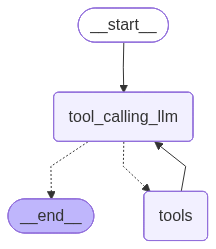

In [57]:
#show the graph

display(Image(graph.get_graph().draw_mermaid_png()))

In [58]:
messages=graph.invoke({"messages":HumanMessage(content=f"provide me the top 10 AI news,and add 5 plus 5 and multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

provide me the top 10 AI news,and add 5 plus 5 and multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (apvmt7axm)
 Call ID: apvmt7axm
  Args:
    query: top 10 AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com", "content": "Retail & Logistics AI\n\nJune 11, 2026\n\n### How C3 AI agents will automate predictive maintenance for Shell\n\nAI in Action\n\nJune 5, 2026\n\n#### Industries\n\n### SAP and Google Cloud deploy agentic commerce architecture\n\nRetail & Logistics AI\n\nJune 19, 2026\n\n### McDonald’s tests Google-backed AI drive-thru ordering system\n\nAI in Action\n\nJune 10, 2026\n\n### Meta Business Agent drive